# 05 | TNEQ Training Workflow

This notebook implements a first end-to-end training loop: a trainable student tensor network learns to match a fixed teacher.

There is no external dataset, making this the clearest place to learn the gradient and optimizer interfaces.


In [1]:
from pathlib import Path
import sys

# This works whether Jupyter starts in the repository root or in notebooks/.
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "tneq_qc").is_dir() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /Users/yuch3n/Documents/Code/Github/tneq-qc


In [2]:
import numpy as np
import torch

from tneq_qc import BackendFactory, EngineCommon, QCTN, create_optimizer

torch.manual_seed(42)
np.random.seed(42)

backend = BackendFactory.create_backend("pytorch", device="cpu", dtype="float32")
engine = EngineCommon(backend=backend, strategy="row_priority")


## 1. Create teacher and student networks

For a small and quick demonstration, one core spans all three qubits. The teacher stays fixed; the student explicitly enables gradients.


In [3]:
N_QUBITS = 3
graph = "\n".join(["-2-A-2-"] * N_QUBITS)

teacher = QCTN(graph, backend=backend).auto_init(orthogonal=True)
student = QCTN(graph, backend=backend).auto_init(orthogonal=True)
student.requires_grad_(True)

print("Teacher:", teacher)
print("Student:", student)


Teacher: QCTN(nqubits=3, cores=[A(2, 2, 2, 2, 2, 2)])
Student: QCTN(nqubits=3, cores=[A(2, 2, 2, 2, 2, 2)])


## 2. Compose and trace the model

Concatenation leaves paired boundaries on each qubit. `set_trace("all")` closes them so the contraction becomes scalar. For a conventional complex inner product you would normally use `teacher.hermit()`; this basic example follows the repository's simple trace-matching pattern.


In [4]:
combined = QCTN.concat([
    ("student", student),
    ("teacher", teacher),
])
combined.set_trace("all")

print("Trainable parameters:")
for name, parameter in combined.named_parameters():
    print(" ", name, parameter.shape)

print("Initial contraction:", engine.contract(combined))


Trainable parameters:
  student.A torch.Size([2, 2, 2, 2, 2, 2])
[Compiler] Strategy candidates: ['row_priority'], Testing 1 strategies...
  [row_priority] Compatibility: True
  [row_priority] Estimated cost: 5.00e+05 FLOPs
[Compiler] Selected strategy: row_priority (cost: 5.00e+05)
Initial contraction: TNTensor(shape=torch.Size([]), scale=1)


## 3. One forward/backward step

`contract_for_gradient()` returns `(loss_value, gradients)`. Gradient order matches `combined.parameters()`.


In [5]:
loss_value, grads = engine.contract_for_gradient(
    combined,
    target=1.0,
    loss="mse",
)

print("Loss:", float(loss_value))
print("Number of gradients:", len(grads))
for index, grad in enumerate(grads):
    print(index, tuple(grad.shape))


Loss: 0.3372129499912262
Number of gradients: 1
0 (2, 2, 2, 2, 2, 2)


## 4. The complete training loop

The current framework favors direct loops instead of the deprecated `Trainer`. Each step contracts the network, computes gradients, and calls `optimizer.step()`.


In [6]:
optimizer = create_optimizer(
    "adam",
    combined.parameters(),
    backend=backend,
    lr=0.01,
)

history = []
for step in range(1, 101):
    loss_value, grads = engine.contract_for_gradient(
        combined,
        target=1.0,
        loss="mse",
    )
    optimizer.step(list(grads))
    history.append(float(loss_value))

    if step == 1 or step % 20 == 0:
        print(f"step={step:3d} loss={history[-1]:.8f}")

print("Initial loss:", history[0])
print("Final loss:", history[-1])
print("Final contraction:", engine.contract(combined))


step=  1 loss=0.33721295
step= 20 loss=0.02062267
step= 40 loss=0.00232839
step= 60 loss=0.00000729
step= 80 loss=0.00005502
step=100 loss=0.00000078
Initial loss: 0.3372129499912262
Final loss: 7.756646027701208e-07
Final contraction: TNTensor(shape=torch.Size([]), scale=1)


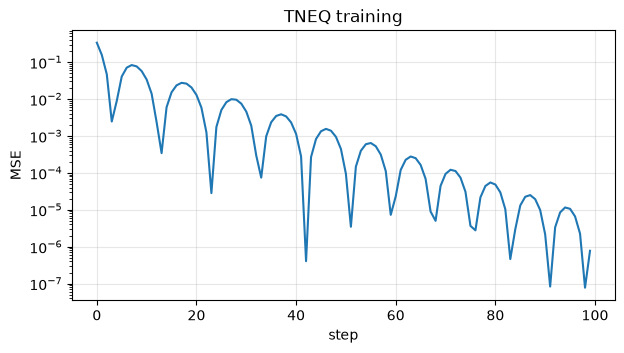

In [7]:
# Optional visualization.
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE")
plt.title("TNEQ training")
plt.grid(alpha=0.3)
plt.show()


## 5. Choosing an optimizer

- `adam`: a reliable default for first experiments;
- `sgd`: simple and useful for debugging;
- `momentum` and `rmsprop`: standard alternatives;
- `sgdg`: designed to preserve Stiefel/orthogonality structure.

### Troubleshooting

- Empty `combined.parameters()`: gradients were not enabled on the student.
- Non-scalar output: one or more external edges remain open.
- No improvement: reduce the learning rate, try Adam, and verify the target and trace structure.
- Unexpected duplicate parameters: Hermitian views should be non-leaf references, not separately trainable cores.

### Exercises

- Compare Adam, SGD, and SGDG.
- Rebuild the overlap using `teacher.hermit()`.
- Increase the number of qubits and measure parameter count and step time.
